# Financial News Topic Modeling and Sentiment Analysis

**Author:** Praveena P
**Integrated MSc + MTech (Computer Science – AI & ML)**
**South Asian University**


## Table of Contents

1. [Project Overview](#1-project-overview)
2. [Import Libraries](#2-import-libraries)
3. [Load Dataset](#3-load-dataset)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Text Preprocessing](#5-text-preprocessing)
6. [Feature Engineering](#6-feature-engineering)
7. [Topic Modeling (LDA)](#7-topic-modeling-lda)
8. [Machine Learning Models](#8-machine-learning-models)
9. [Transformer-based Sentiment Analysis](#9-transformer-based-sentiment-analysis)
10. [Results](#10-results)
11. [Future Work](#11-future-work)
12. [Conclusion](#12-conclusion)


## 1. Project Overview

This project explores the **FinancialPhraseBank** dataset (financial news sentences labeled as *positive*, *negative*, or *neutral*) through two complementary NLP lenses:

- **Unsupervised topic discovery** using Latent Dirichlet Allocation (LDA) to surface the latent themes present in financial news text.
- **Supervised sentiment classification** using three modelling families of increasing complexity: classical machine learning on TF-IDF and Word2Vec features, and a pretrained Transformer (RoBERTa) model.

**Why this matters:** sentiment in financial news is a widely used signal in trading and risk research, and comparing lightweight classical models against a large pretrained Transformer illustrates the practical trade-offs between accuracy, interpretability, and compute cost.

**What to expect:** the notebook walks through data acquisition, preprocessing, feature engineering, topic modeling, model training, and a final side-by-side evaluation of all approaches.


## 2. Import Libraries

**Why:** every library used in the notebook is centralized in a single cell so dependencies are easy to audit and install.

**What's used:** `pandas`/`numpy` for data handling, `nltk`/`spaCy` for text preprocessing, `scikit-learn` for feature extraction and classical ML, `gensim` for topic modeling and word embeddings, `transformers`/`torch` for the pretrained sentiment model, and `matplotlib`/`seaborn` for visualization.

**Expected output:** confirmation that the required NLTK corpora downloaded successfully.


In [ ]:
# Standard library
import os
import re
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset encoding detection
import chardet

# NLTK - text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# spaCy - text preprocessing
import spacy

# scikit-learn - preprocessing, features, models, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Gensim - topic modeling and word embeddings
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel, Word2Vec

# Transformers - pretrained sentiment classifier
import torch
from transformers import pipeline

warnings.filterwarnings('ignore')

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 3. Load Dataset

**Why:** the dataset is loaded from a local CSV rather than downloaded automatically, keeping the notebook self-contained and GitHub-friendly (no external API calls or credentials required to run it).

> **Note:** this notebook expects the dataset to already exist locally at `data/all-data.csv`. Download the **Sentiment Analysis for Financial News** dataset from Kaggle (https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news) and place the CSV at that path before running this notebook. The dataset itself is **not** included in this repository.

**What happens:** the CSV's text encoding is auto-detected with `chardet`, rows are shuffled with a fixed random seed for reproducibility, and sentiment labels are numerically encoded for downstream modeling.

**Expected output:** a confirmation of the number of samples and columns loaded.


In [ ]:
# Path to the locally stored dataset (see note above)
csv_path = os.path.join('data', 'all-data.csv')

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        "Dataset not found at 'data/all-data.csv'. Please download the "
        "'Sentiment Analysis for Financial News' dataset from Kaggle "
        "(https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news) "
        "and place the CSV file at data/all-data.csv."
    )


def detect_encoding_and_load(csv_path):
    """Load a CSV file using its automatically detected text encoding."""
    with open(csv_path, 'rb') as f:
        raw = f.read(20000)  # sample first 20 KB
    guess = chardet.detect(raw)
    enc = guess['encoding'] or 'utf-8'
    try:
        df = pd.read_csv(csv_path, encoding=enc, on_bad_lines='skip')
    except Exception:
        print(f"Failed to read CSV with encoding {enc}. Trying utf-8...")
        df = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines='skip')
    return df


# Load data
print("\n[Step 1] Loading data...")
df = detect_encoding_and_load(csv_path)
df = df.sample(n=df.shape[0], random_state=42).reset_index(drop=True)

# Assign column names
if len(df.columns) == 2:
    df.columns = ['sentiment', 'text']
else:
    raise ValueError("The dataset does not have exactly two columns.")

# Fill missing text values with empty strings
df['text'] = df['text'].fillna('')

# Encode sentiment labels (negative / neutral / positive -> integers)
label_encoder = LabelEncoder()
df['sentiment_encoder'] = label_encoder.fit_transform(df['sentiment'])

# Convenience lists used throughout the notebook
sample_texts = df['text'].tolist()
sample_labels = df['sentiment_encoder'].tolist()

print(f"Dataset: {len(df)} samples")
print(f"Columns: {df.columns.tolist()}")



[Step 1] Loading data...
Dataset: 4845 samples
Columns: ['sentiment', 'text']


## 4. Exploratory Data Analysis

**Why:** a quick sanity check of the loaded data catches issues (missing values, unexpected label values) before any modeling begins.

**What's checked:** missing-value counts, the set of sentiment labels, and a preview of the raw rows.

**Expected output:** zero missing values, three sentiment classes (`negative`, `neutral`, `positive`), and a preview table of the first few rows.


In [ ]:
# Missing values and label distribution
print("Missing Values:\n", df.isnull().sum())
print("\nUnique Sentiment Labels:\n", df['sentiment'].unique())

# Preview the dataset
df.head()



Missing Values:
 sentiment    0
text         0
dtype: int64

Unique Sentiment Labels:
 ['neutral' 'positive' 'negative']


,sentiment,text,sentiment_encoder
0,neutral,The company was supposed to deliver machinery ...,1
1,positive,UPM-Kymmene has generated four consecutive qua...,2
2,neutral,In the method the smelt spouts 2 are separated...,1
3,neutral,`` That 's a very high figure on the European ...,1
4,neutral,"In Penttil+Æ 's vision , the most important re...",1


## 5. Text Preprocessing

**Why:** raw financial news sentences are noisy and cannot be fed directly into either statistical or neural models.

**What's used:** the `TextPreprocessor` class implements a configurable cleaning pipeline with two interchangeable backends:

1. **Cleaning** - lowercasing, and removal of URLs, emails, mentions/hashtags, and non-alphabetic characters.
2. **NLTK pipeline** - tokenization, short-token removal, stopword removal, and lemmatization.
3. **spaCy pipeline** - lemmatization with built-in stopword and punctuation filtering, used as a faster and linguistically richer alternative to the NLTK path.

Both pipelines are run so their outputs can be compared; the spaCy output (`processed_docs2`) is used for feature engineering downstream.

**Expected output:** one sample sentence shown as tokenized/cleaned text from each pipeline.


In [ ]:
class TextPreprocessor:
    """
    Comprehensive text preprocessing class
    """

    def __init__(self, use_spacy=False):
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        self.stop_words = set(stopwords.words('english'))
        self.use_spacy = use_spacy

        if use_spacy:
            # Load spaCy model
            self.nlp = spacy.load('en_core_web_sm')

    def clean_text(self, text):
        """Remove special characters, URLs, emails, etc."""
        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)

        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)

        # Remove mentions and hashtags (for social media)
        text = re.sub(r'@\w+|#\w+', '', text)

        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def preprocess_with_nltk(self, text):
        """
        Complete preprocessing pipeline using NLTK

        Steps:
        1. Clean text
        2. Tokenize
        3. Remove stopwords
        4. Lemmatize
        """
        # Clean
        cleaned = self.clean_text(text)

        # Tokenize
        tokens = word_tokenize(cleaned)

        # Remove short tokens (length < 3)
        tokens = [token for token in tokens if len(token) > 2]

        # Remove stopwords
        tokens = self.remove_stopwords(tokens)

        # Lemmatize
        tokens = self.lemmatize_tokens(tokens)

        return tokens

    def preprocess_with_spacy(self, text):
        """
        Complete preprocessing pipeline using spaCy

        Advantages of spaCy:
        - Faster processing
        - Better lemmatization
        - Part-of-speech tagging
        - Named entity recognition
        """
        # Clean
        cleaned = self.clean_text(text)

        # Process with spaCy
        doc = self.nlp(cleaned)

        # Extract lemmas, remove stopwords and punctuation
        tokens = [
            token.lemma_ for token in doc
            if not token.is_stop
            and not token.is_punct
            and len(token.text) > 2
        ]

        return tokens

    def preprocess(self, text):
        """Main preprocessing method"""
        if self.use_spacy:
            return self.preprocess_with_spacy(text)
        else:
            return self.preprocess_with_nltk(text)

    def preprocess_corpus(self, texts):
        """Preprocess entire corpus"""
        return [self.preprocess(text) for text in texts]

    def remove_stopwords(self, tokens):
        """Remove stopwords from token list"""
        return [token for token in tokens if token not in self.stop_words]

    def lemmatize_tokens(self, tokens):
        """Lemmatize tokens to their base form"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]

    def stem_tokens(self, tokens):
        """Stem tokens to their root form"""
        return [self.stemmer.stem(token) for token in tokens]


# Step 2: Preprocess
print("\n[Step 2] Preprocessing text...")
preprocessor_nltk = TextPreprocessor(use_spacy=False)
processed_docs1 = preprocessor_nltk.preprocess_corpus(sample_texts)
print(f"Sample processed [NLTK]: {processed_docs1[0:1]}")

preprocessor_spacy = TextPreprocessor(use_spacy=True)
processed_docs2 = preprocessor_spacy.preprocess_corpus(sample_texts)
print(f"Sample processed [SpaCy]: {processed_docs2[0:1]}")


[Step 2] Preprocessing text...
Sample processed [NLTK]: [['company', 'supposed', 'deliver', 'machinery', 'veneer', 'mill', 'tomsk', 'region', 'russia']]
Sample processed [SpaCy]: [['company', 'suppose', 'deliver', 'machinery', 'veneer', 'mill', 'tomsk', 'region', 'russia']]


## 6. Feature Engineering

**Why:** two complementary text representations are built from the preprocessed tokens so their downstream classification performance can be compared.

### 6.1 TF-IDF

**What it does:** Term Frequency-Inverse Document Frequency weights each word (and bigram) by how distinctive it is to a document relative to the corpus, producing a sparse, high-dimensional bag-of-words style representation that classical linear models tend to work well with.

**Expected output:** the resulting matrix shape and the top TF-IDF terms for a few sample documents.


In [ ]:
class TFIDFFeatureExtractor:
    """
    TF-IDF (Term Frequency-Inverse Document Frequency) feature extraction
    """

    def __init__(self, max_features=5000, ngram_range=(1, 2)):
        """
        Initialize TF-IDF vectorizer

        Parameters:
        -----------
        max_features : int
            Maximum number of features to extract
        ngram_range : tuple
            Range of n-grams to extract (e.g., (1,2) for unigrams and bigrams)
        """
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            max_df=0.85,  # Ignore terms that appear in > 85% of documents
            min_df=2       # Ignore terms that appear in < 2 documents
        )

    def fit_transform(self, documents):
        """
        Fit vectorizer and transform documents

        Parameters:
        -----------
        documents : list
            List of preprocessed documents (as token lists)

        Returns:
        --------
        sparse matrix
            TF-IDF feature matrix
        """
        # Join tokens back into strings
        text_docs = [' '.join(doc) for doc in documents]

        # Fit and transform
        tfidf_matrix = self.vectorizer.fit_transform(text_docs)

        print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
        print(f"Number of features: {len(self.vectorizer.get_feature_names_out())}")

        return tfidf_matrix

    def transform(self, documents):
        """Transform new documents"""
        text_docs = [' '.join(doc) for doc in documents]
        return self.vectorizer.transform(text_docs)

    def get_feature_names(self):
        """Get feature names"""
        return self.vectorizer.get_feature_names_out()

# Step 3: TF-IDF
print("\n[Step 3] Generating TF-IDF features...")
tfidf_extractor = TFIDFFeatureExtractor(max_features=1000)
tfidf_matrix = tfidf_extractor.fit_transform(processed_docs2)

# Optional: Visualize top features
def visualize_top_features(tfidf_matrix, feature_names, top_n=10, num_docs=5):
    """
    Visualize the top N features for a subset of documents

    Parameters:
    -----------
    tfidf_matrix : sparse matrix
        TF-IDF feature matrix
    feature_names : array
        Array of feature names
    top_n : int
        Number of top features to display
    num_docs : int
        Number of documents to display top features for
    """
    dense_tfidf = tfidf_matrix[:num_docs].todense()  # Limit to num_docs documents
    df_tfidf = pd.DataFrame(dense_tfidf, columns=feature_names)

    # Get top N features for each document
    top_features = pd.DataFrame(index=range(num_docs), columns=[f'Document_{i}' for i in range(num_docs)])
    for i in range(num_docs):
        top_features.iloc[i] = df_tfidf.iloc[i].nlargest(top_n).index

    print(top_features)

# Visualize top features for the first 5 documents
feature_names = tfidf_extractor.get_feature_names()
visualize_top_features(tfidf_matrix, feature_names, top_n=5, num_docs=5)


[Step 3] Generating TF-IDF features...
TF-IDF matrix shape: (4845, 1000)
Number of features: 1000
   Document_0   Document_1 Document_2 Document_3 Document_4
0      region    machinery       mill    deliver     russia
1  upmkymmene    cash flow       flow   positive   generate
2      method         work       area       able     access
3      figure         beer   european        buy       high
4   important  transaction     russia       able     access


### 6.2 Word2Vec

**What it does:** Word2Vec (Skip-gram) learns dense, semantically meaningful word vectors from co-occurrence patterns in the corpus. Document-level vectors are obtained by averaging the embeddings of the tokens in each document, giving a compact dense representation that captures semantic similarity rather than raw term frequency.

**Expected output:** the trained vocabulary size and the most similar words for a few sample finance-related terms.


In [ ]:
class Word2VecEmbeddings:
    """
    Word2Vec embeddings using Gensim

    Two architectures:
    - CBOW (Continuous Bag of Words): Predicts target word from context
    - Skip-gram: Predicts context words from target word
    """

    def __init__(self, vector_size=100, window=5, min_count=2, sg=0):
        """
        Initialize Word2Vec model

        Parameters:
        -----------
        vector_size : int
            Dimensionality of word vectors
        window : int
            Maximum distance between current and predicted word
        min_count : int
            Minimum word frequency
        sg : int
            Training algorithm: 0 for CBOW, 1 for Skip-gram
        """
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.model = None

    def train(self, sentences):
        """
        Train Word2Vec model

        Parameters:
        -----------
        sentences : list of lists
            Tokenized sentences
        """
        self.model = Word2Vec(
            sentences=sentences,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            sg=self.sg,
            workers=4
        )

        print(f"Word2Vec model trained")
        print(f"Vocabulary size: {len(self.model.wv)}")
        print(f"Architecture: {'Skip-gram' if self.sg else 'CBOW'}")

    def get_word_vector(self, word):
        """Get vector for a word"""
        try:
            return self.model.wv[word]
        except KeyError:
            return None

    def most_similar(self, word, topn=10):
        """Find most similar words"""
        try:
            return self.model.wv.most_similar(word, topn=topn)
        except KeyError:
            return []

    def document_vector(self, tokens):
        """
        Create document vector by averaging word vectors
        """
        vectors = []
        for token in tokens:
            try:
                vectors.append(self.model.wv[token])
            except KeyError:
                continue

        if vectors:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(self.vector_size)

# Step 4: Word2Vec
print("\n[Step 4] Training Word2Vec embeddings...")
w2v = Word2VecEmbeddings(vector_size=100, sg=1)  # Skip-gram
w2v.train(processed_docs2)

# Generate Word2Vec document vectors
w2v_document_vectors = np.array([w2v.document_vector(doc) for doc in processed_docs2])

# Optional: Visualize most similar words for multiple sample words
def visualize_most_similar(w2v_model, words, topn=10):
    """
    Visualize the most similar words for a list of sample words

    Parameters:
    -----------
    w2v_model : Word2VecEmbeddings
        Trained Word2Vec model
    words : list of str
        List of words to find similar words for
    topn : int
        Number of similar words to display
    """
    for word in words:
        similar_words = w2v_model.most_similar(word, topn=topn)
        print(f"\nMost similar words to '{word}':")
        for sim_word, similarity in similar_words:
            print(f"{sim_word}: {similarity:.4f}")

# Visualize most similar words for five sample words
sample_words = ['market', 'stock', 'company', 'financial', 'news']
visualize_most_similar(w2v, sample_words, topn=5)


[Step 4] Training Word2Vec embeddings...
Word2Vec model trained
Vocabulary size: 3654
Architecture: Skip-gram

Most similar words to 'market':
new: 0.9665
give: 0.9544
follow: 0.9506
baltic: 0.9395
offer: 0.9391

Most similar words to 'stock':
exchange: 0.9657
release: 0.9325
corporation: 0.9165
option: 0.9083
helsinki: 0.9076

Most similar words to 'company':
raivv: 0.9905
amea: 0.9898
tikanoja: 0.9889
afev: 0.9889
january: 0.9889

Most similar words to 'financial':
ftse: 0.9820
fullyear: 0.9814
talentum: 0.9811
firstquarter: 0.9810
publish: 0.9809

Most similar words to 'news':
adp: 0.9922
feb: 0.9860
industrial: 0.9854
president: 0.9842
security: 0.9835


## 7. Topic Modeling (LDA)

**Why:** Latent Dirichlet Allocation is used to uncover the latent topics present in the financial news corpus in an unsupervised manner, complementing the supervised sentiment task with a qualitative view of the data.

**What's used:** a Gensim dictionary and bag-of-words corpus built from the preprocessed tokens, used to train an LDA model. The resulting topics are inspected as both top-word lists and word-cloud visualizations, and topic quality is quantified with the `c_v` coherence score.

**Expected output:** a list of topics with their top words, a coherence score, and word-cloud plots for each topic.



[Step 5] Performing topic modeling with LDA...
Dictionary size: 3552
Corpus size: 4845
LDA model trained with 6 topics

Topic 0:
share, company, capital, percent, stock

Topic 1:
eur, sale, profit, net, million

Topic 2:
service, finland, customer, company, system

Topic 3:
say, company, finnish, oyj, hel

Topic 4:
finland, company, operation, start, bank

Topic 5:
mln, euro, say, value, order

Coherence Score: 0.4202


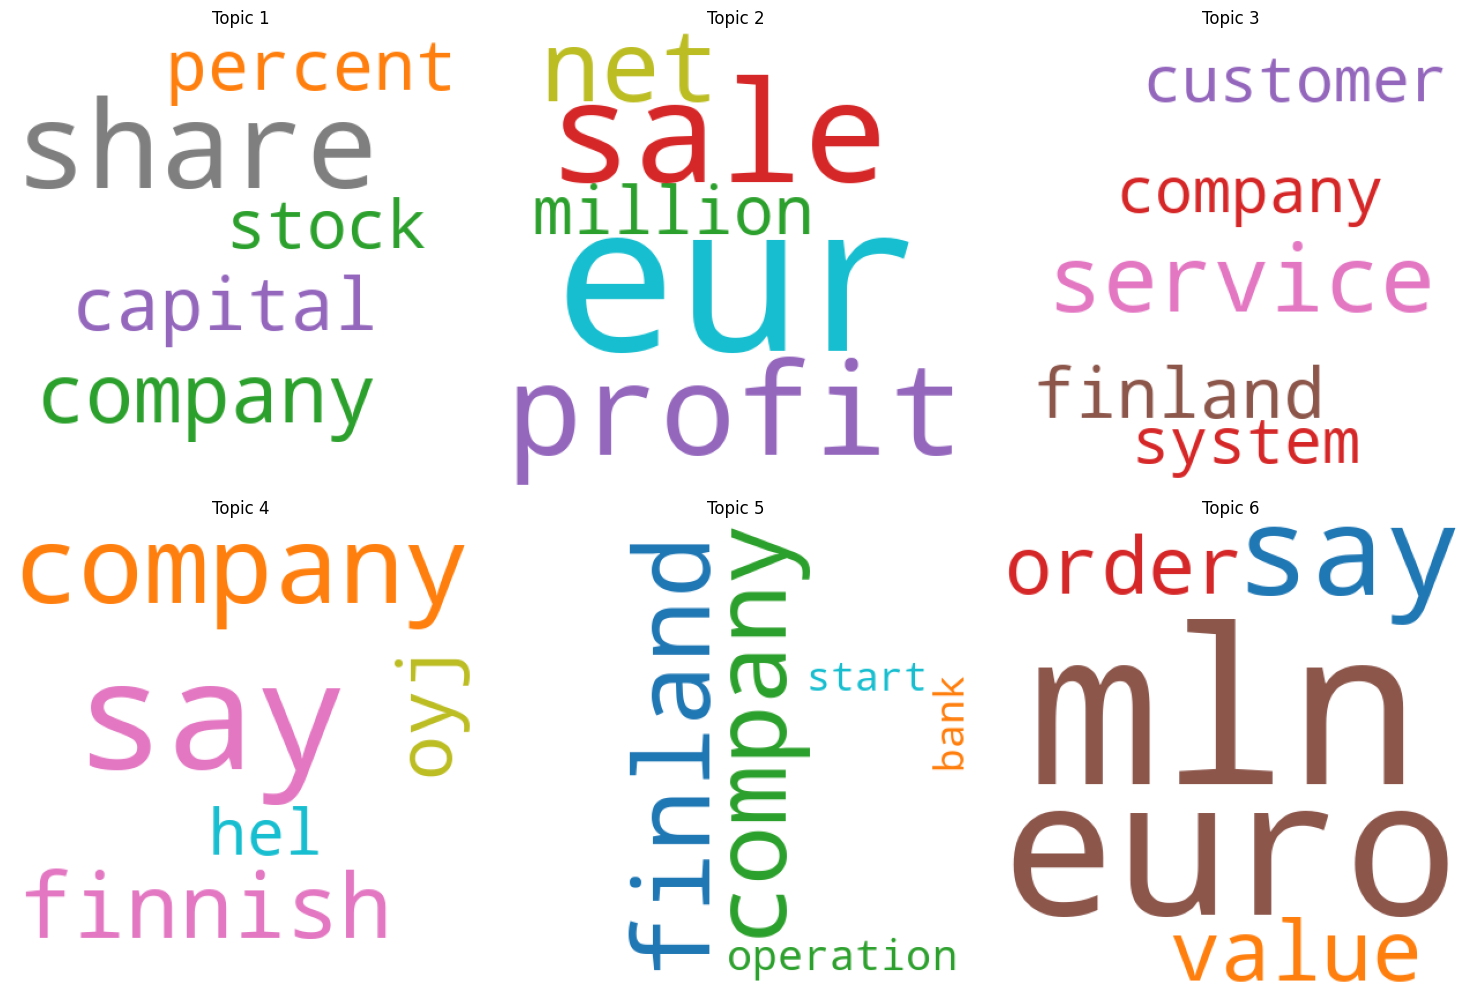

In [ ]:
class LDATopicModeler:
    """
    Latent Dirichlet Allocation (LDA) for topic modeling using Gensim
    """

    def __init__(self, num_topics=10, passes=10, random_state=42):
        """
        Initialize LDA model

        Parameters:
        -----------
        num_topics : int
            Number of topics to extract
        passes : int
            Number of passes through the corpus
        random_state : int
            Random seed for reproducibility
        """
        self.num_topics = num_topics
        self.passes = passes
        self.random_state = random_state
        self.model = None
        self.dictionary = None
        self.corpus = None

    def prepare_corpus(self, documents):
        """
        Prepare corpus for LDA

        Parameters:
        -----------
        documents : list of lists
            Tokenized documents
        """
        # Create dictionary
        self.dictionary = corpora.Dictionary(documents)

        # Filter extremes
        self.dictionary.filter_extremes(no_below=2, no_above=0.85)

        # Create corpus (bag of words)
        self.corpus = [self.dictionary.doc2bow(doc) for doc in documents]

        print(f"Dictionary size: {len(self.dictionary)}")
        print(f"Corpus size: {len(self.corpus)}")

    def train(self, documents=None):
        """
        Train LDA model
        """
        if documents:
            self.prepare_corpus(documents)

        # Train LDA model
        self.model = LdaModel(
            corpus=self.corpus,
            id2word=self.dictionary,
            num_topics=self.num_topics,
            random_state=self.random_state,
            passes=self.passes,
            alpha='symmetric',        # instead of 'auto'
            eta='symmetric',          # instead of 'auto'
            per_word_topics=True
        )

        print(f"LDA model trained with {self.num_topics} topics")

    def get_topics(self, num_words=10):
        """Get top words for each topic"""
        topics = []
        for idx in range(self.num_topics):
            topic = self.model.show_topic(idx, num_words)
            topics.append(topic)
            print(f"\nTopic {idx}:")
            print(', '.join([word for word, _ in topic]))
        return topics

    def get_document_topics(self, document):
        """Get topic distribution for a document"""
        bow = self.dictionary.doc2bow(document)
        return self.model.get_document_topics(bow)

    def calculate_coherence(self, documents):
        """Calculate coherence score"""
        coherence_model = CoherenceModel(
            model=self.model,
            texts=documents,
            dictionary=self.dictionary,
            coherence='c_v'
        )
        coherence_score = coherence_model.get_coherence()
        print(f"\nCoherence Score: {coherence_score:.4f}")
        return coherence_score

    def visualize_topics(self, num_words=10):
        """Visualize topics with word clouds"""
        from wordcloud import WordCloud
        import matplotlib.pyplot as plt

        num_plots = self.num_topics
        num_cols = 3
        num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate number of rows needed

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), sharex=True, sharey=True)

        for i, ax in enumerate(axes.flatten()):
            if i < num_plots:
                fig.add_subplot(ax)
                topic_words = dict(self.model.show_topic(i, topn=num_words))
                cloud = WordCloud(width=400, height=400, background_color='white', colormap='tab10')
                cloud.generate_from_frequencies(topic_words)
                plt.gca().imshow(cloud)
                plt.gca().set_title(f'Topic {i + 1}')
                plt.gca().axis('off')
            else:
                ax.axis('off')  # Turn off unused subplots

        plt.tight_layout()
        plt.show()

# Step 5: Topic Modeling
print("\n[Step 5] Performing topic modeling with LDA...")
lda = LDATopicModeler(num_topics=6, passes=20)
lda.train(processed_docs2)
topics = lda.get_topics(num_words=5)
coherence = lda.calculate_coherence(processed_docs2)

# Visualize topics
lda.visualize_topics(num_words=5)

## 8. Machine Learning Models

**Why:** classical linear classifiers provide a fast, interpretable baseline for sentiment classification, evaluated on both feature sets from Section 6.

### 8.1 Logistic Regression
A probabilistic linear classifier that models class probabilities directly and serves as a strong, interpretable baseline.

### 8.2 Linear SVM
A margin-maximizing linear classifier (`LinearSVC`), typically robust on high-dimensional sparse text features such as TF-IDF.

**What's compared:** both models are trained on the TF-IDF matrix and on the Word2Vec document vectors, giving four model/feature combinations in total.

**Expected output:** accuracy, a full classification report, and a confusion matrix for each combination, plus a final bar chart comparing all four.



[Step 6] Training ML sentiment classifier with TF-IDF features...
logistic model trained

Accuracy: 0.7595

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.43      0.53       115
           1       0.79      0.91      0.85       601
           2       0.67      0.55      0.61       253

    accuracy                           0.76       969
   macro avg       0.72      0.63      0.66       969
weighted avg       0.75      0.76      0.75       969



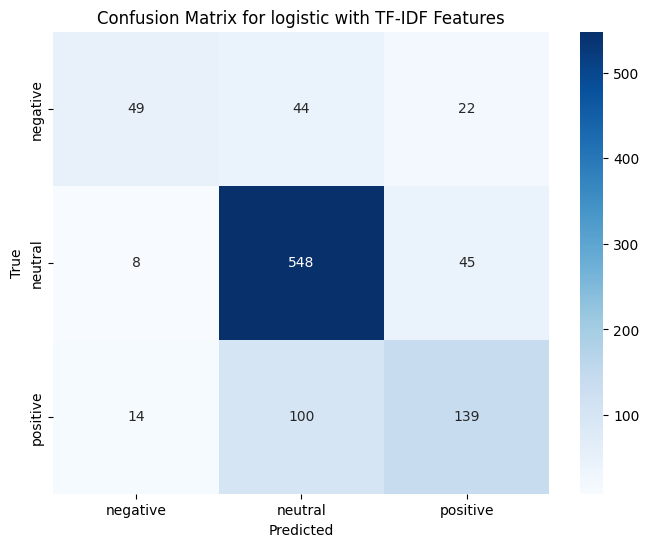

svm model trained

Accuracy: 0.7585

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.57      0.61       115
           1       0.83      0.85      0.84       601
           2       0.63      0.63      0.63       253

    accuracy                           0.76       969
   macro avg       0.70      0.68      0.69       969
weighted avg       0.76      0.76      0.76       969



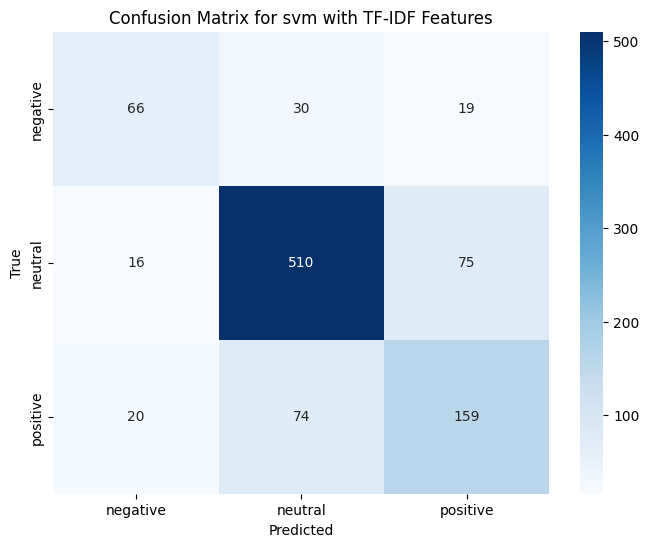


[Step 7] Training ML sentiment classifier with Word2Vec features...
logistic model trained

Accuracy: 0.6533

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.06      0.11       115
           1       0.70      0.92      0.80       601
           2       0.43      0.28      0.34       253

    accuracy                           0.65       969
   macro avg       0.56      0.42      0.42       969
weighted avg       0.61      0.65      0.60       969



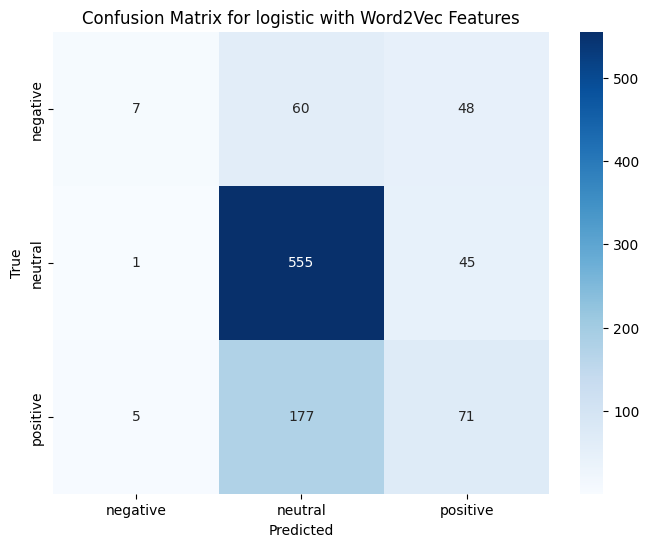

svm model trained

Accuracy: 0.6553

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.03      0.05       115
           1       0.70      0.93      0.80       601
           2       0.45      0.29      0.35       253

    accuracy                           0.66       969
   macro avg       0.51      0.41      0.40       969
weighted avg       0.60      0.66      0.59       969



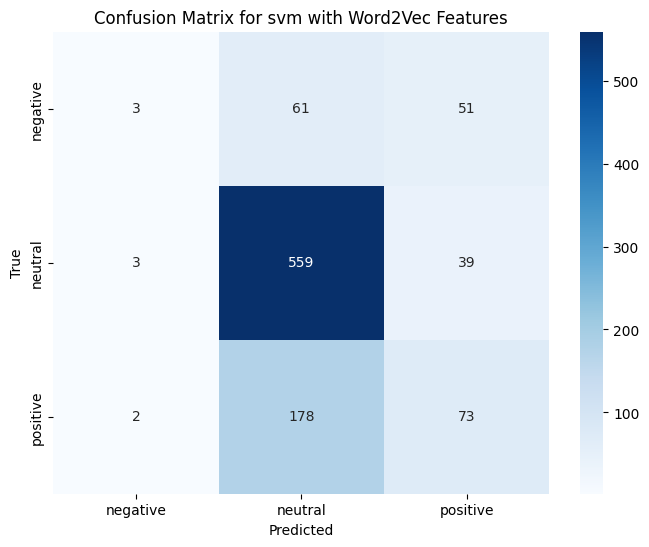


Results with TF-IDF features:
logistic: 0.7595
svm: 0.7585

Results with Word2Vec features:
logistic: 0.6533
svm: 0.6553


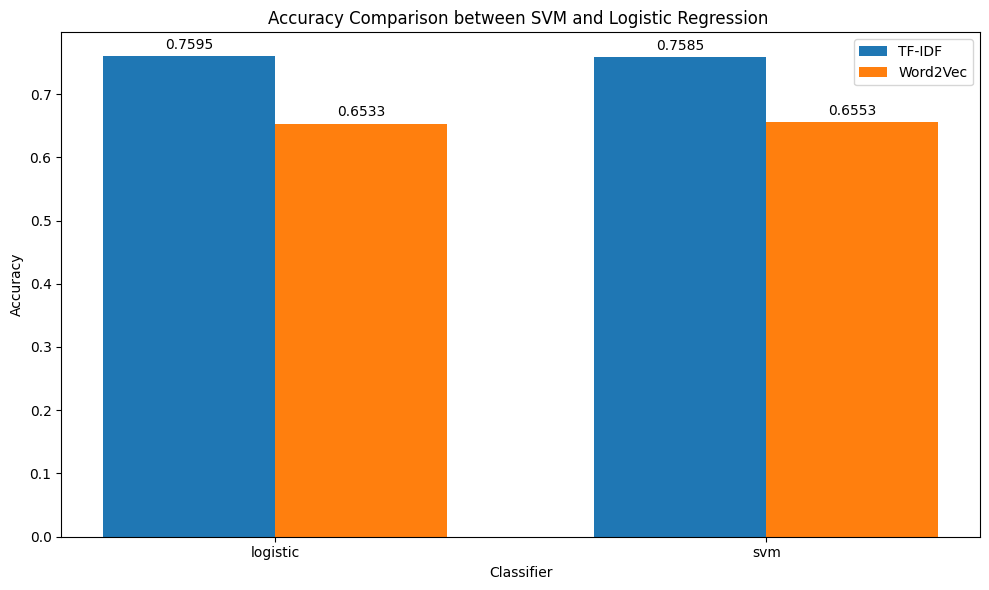

In [ ]:
class MLSentimentClassifier:
    """
    Machine Learning based sentiment classifier
    """

    def __init__(self, model_type='logistic', feature_set_name='TF-IDF'):
        """
        Initialize classifier

        Parameters:
        -----------
        model_type : str
            Type of classifier: 'logistic' or 'svm'
        feature_set_name : str
            Name of the feature set: 'TF-IDF' or 'Word2Vec'
        """
        if model_type == 'logistic':
            self.model = LogisticRegression(max_iter=1000, random_state=42)
        elif model_type == 'svm':
            self.model = LinearSVC(random_state=42)
        else:
            raise ValueError("Invalid model type for Word2Vec features. Use 'logistic' or 'svm'.")

        self.model_type = model_type
        self.feature_set_name = feature_set_name

    def train(self, X_train, y_train):
        """Train the model"""
        self.model.fit(X_train, y_train)
        print(f"{self.model_type} model trained")

    def predict(self, X_test):
        """Make predictions"""
        return self.model.predict(X_test)

    def evaluate(self, X_test, y_test):
        """Evaluate the model"""
        y_pred = self.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        print(f"\nAccuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(report)

        # Plot confusion matrix
        self.plot_confusion_matrix(y_test, y_pred)

        return accuracy, report

    def plot_confusion_matrix(self, y_test, y_pred):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'Confusion Matrix for {self.model_type} with {self.feature_set_name} Features')
        plt.show()

# Function to train and evaluate classifiers
def train_and_evaluate_classifiers(X_train, X_test, y_train, y_test, feature_set_name):
    classifiers = ['logistic', 'svm']
    results = {}

    for model_type in classifiers:
        ml_classifier = MLSentimentClassifier(model_type=model_type, feature_set_name=feature_set_name)
        ml_classifier.train(X_train, y_train)
        accuracy, report = ml_classifier.evaluate(X_test, y_test)
        results[model_type] = accuracy

    return results

# Split data for TF-IDF features
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(tfidf_matrix, sample_labels, test_size=0.2, random_state=42)

# Split data for Word2Vec features
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(w2v_document_vectors, sample_labels, test_size=0.2, random_state=42)

# Train and evaluate classifiers with TF-IDF features
print("\n[Step 6] Training ML sentiment classifier with TF-IDF features...")
results_tfidf = train_and_evaluate_classifiers(X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')

# Train and evaluate classifiers with Word2Vec features
print("\n[Step 7] Training ML sentiment classifier with Word2Vec features...")
results_w2v = train_and_evaluate_classifiers(X_train_w2v, X_test_w2v, y_train, y_test, 'Word2Vec')

# Print results
print("\nResults with TF-IDF features:")
for model_type, accuracy in results_tfidf.items():
    print(f"{model_type}: {accuracy:.4f}")

print("\nResults with Word2Vec features:")
for model_type, accuracy in results_w2v.items():
    print(f"{model_type}: {accuracy:.4f}")

# Visualization of results
def plot_accuracy_comparison(results_tfidf, results_w2v):
    """
    Plot accuracy comparison between TF-IDF and Word2Vec features

    Parameters:
    -----------
    results_tfidf : dict
        Accuracy results for TF-IDF features
    results_w2v : dict
        Accuracy results for Word2Vec features
    """
    classifiers = list(results_tfidf.keys())
    accuracies_tfidf = [results_tfidf[model] for model in classifiers]
    accuracies_w2v = [results_w2v[model] for model in classifiers]

    x = np.arange(len(classifiers))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, accuracies_tfidf, width, label='TF-IDF')
    rects2 = ax.bar(x + width/2, accuracies_w2v, width, label='Word2Vec')

    # Add some text for labels, title, and custom x-axis tick labels, etc.
    ax.set_xlabel('Classifier')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Comparison between SVM and Logistic Regression ')
    ax.set_xticks(x)
    ax.set_xticklabels(classifiers)
    ax.legend()

    # Add labels on top of bars
    def autolabel(rects):
        """Attach a text label above each bar in *rects*, displaying its height."""
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()

    plt.show()

# Plot accuracy comparison
plot_accuracy_comparison(results_tfidf, results_w2v)


## 9. Transformer-based Sentiment Analysis

**Why:** as a strong pretrained baseline, a Transformer model is applied without any fine-tuning to see how a general-purpose sentiment model performs on domain-specific financial text.

**What's used:** `siebert/sentiment-roberta-large-english` - a RoBERTa model fine-tuned for binary sentiment analysis - applied to the same held-out test split via Hugging Face's `sentiment-analysis` pipeline. Predicted labels are mapped to the dataset's label space and compared against the true labels.

**Expected output:** sample predictions and an overall accuracy score.


In [ ]:
class TransformerSentimentClassifier:
    """
    Transformer-based sentiment classifier using Hugging Face
    """

    def __init__(self, model_name='siebert/sentiment-roberta-large-english'):
        """
        Initialize transformer model

        Popular models:
        - 'distilbert-base-uncased-finetuned-sst-2-english'
        - 'bert-base-uncased'
        - 'roberta-base'
        - 'siebert/sentiment-roberta-large-english'
        """
        self.model_name = model_name

        # Load pre-trained sentiment analysis pipeline
        self.classifier = pipeline(
            'sentiment-analysis',
            model=model_name,
            device=0 if torch.cuda.is_available() else -1
        )

        print(f"Loaded transformer model: {model_name}")

    def predict(self, texts, batch_size=32):
        """
        Predict sentiment for texts

        Parameters:
        -----------
        texts : list
            List of text strings
        batch_size : int
            Batch size for processing

        Returns:
        --------
        list
            List of predictions
        """
        predictions = []

        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            results = self.classifier(batch)
            predictions.extend(results)

        return predictions

    def evaluate(self, texts, true_labels):
        """Evaluate transformer model"""
        predictions = self.predict(texts)

        # Extract predicted labels
        pred_labels = [pred['label'] for pred in predictions]

        # Map to binary if needed
        label_map = {'POSITIVE': 1, 'NEGATIVE': 0, 'NEUTRAL': 0.5}
        pred_labels = [label_map.get(label, label) for label in pred_labels]

        accuracy = accuracy_score(true_labels, pred_labels)

        print(f"\nTransformer Accuracy: {accuracy:.4f}")

        return accuracy

indices = range(len(sample_texts))
_, test_indices = train_test_split(indices, test_size=0.2, random_state=42)
test_indices = list(test_indices)

test_texts = [sample_texts[i] for i in test_indices]
test_labels = [sample_labels[i] for i in test_indices]

# Step 7: Sentiment Classification (Transformers)
print("\n[Step 7] Using transformer for sentiment analysis...")
transformer_clf = TransformerSentimentClassifier()
transformer_preds = transformer_clf.predict(sample_texts[:2])

print(f"Sample predictions: {transformer_preds}")
transformer_clf.evaluate(test_texts, test_labels)



[Step 7] Using transformer for sentiment analysis...


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


Loaded transformer model: siebert/sentiment-roberta-large-english
Sample predictions: [{'label': 'NEGATIVE', 'score': 0.9967541098594666}, {'label': 'POSITIVE', 'score': 0.9986489415168762}]

Transformer Accuracy: 0.6336


0.6336429308565531

## 10. Results

| Model | Feature Representation | Accuracy |
|---|---|---|
| Logistic Regression | TF-IDF | 0.7595 |
| Linear SVM | TF-IDF | 0.7585 |
| Logistic Regression | Word2Vec | 0.6533 |
| Linear SVM | Word2Vec | 0.6553 |
| RoBERTa (pretrained, zero-shot) | Raw text | 0.6336 |

**Interpretation:** TF-IDF features paired with linear classifiers (Logistic Regression and Linear SVM) clearly outperform Word2Vec-based averaged embeddings on this dataset, both reaching roughly 76% accuracy compared to ~65%. This suggests that, for this relatively small, domain-specific corpus, sparse lexical features capture the sentiment signal in financial news more effectively than averaged dense embeddings. The off-the-shelf RoBERTa model, despite being a much larger pretrained Transformer, underperforms the TF-IDF baselines (63.4%) since it was not fine-tuned on financial text and its binary positive/negative label space does not natively align with the dataset's three-class (negative/neutral/positive) scheme. The LDA topic model additionally surfaced six coherent themes (e.g. shares/profit, sales/EUR figures, Finnish company operations) with a coherence score of 0.42, providing useful qualitative insight into the corpus beyond the classification task.


## 11. Future Work

Potential extensions of this project include:

- **Hyperparameter optimization** for the TF-IDF vectorizer and the classical ML models (e.g. grid/random search over regularization strength, n-gram range, and vocabulary size).
- **Fine-tuning larger Transformer models** (e.g. FinBERT or a domain-adapted RoBERTa) directly on the financial sentiment labels, rather than relying on a zero-shot pretrained model.
- **BERTopic** as a neural alternative to LDA for topic modeling, potentially yielding more coherent and interpretable topics.
- **Aspect-Based Sentiment Analysis (ABSA)** to identify sentiment toward specific entities or financial metrics within a sentence, rather than a single sentence-level label.
- **Deployment as a web application** (e.g. via Streamlit or a simple Flask/FastAPI service) to make the trained models interactively queryable.
- **Multilingual financial news analysis**, extending the pipeline to non-English financial news sources.


## 12. Conclusion

This project implemented an end-to-end NLP pipeline for financial news analysis, combining unsupervised topic modeling with supervised sentiment classification across three feature/model paradigms: sparse lexical (TF-IDF), dense static embeddings (Word2Vec), and a pretrained Transformer (RoBERTa). The classical TF-IDF + linear model combination proved the most effective for this dataset, highlighting that simpler, well-tuned representations can outperform more sophisticated embeddings or zero-shot pretrained models on small, domain-specific text corpora. The Future Work section above outlines natural next steps for extending this analysis.
